In [15]:
'''
CRAG 프로세스를 채택하여서, 강의자료와 관련없는 내용에 대해서도 강건성을 확보했다.
document_path (str) : pdf 강의자료의 경로다.
question (str) : STT 반환 서버에서의 텍스트가 들어갈 주석 텍스트
answer (str) : CRAG 프로세스를 거친후, AI의 주석관련 내용 요약 및 정리 텍스트.

예시.
document_path = "data/10 Vector Calculus.pdf"
question = "삼성전자가 개발한 생성형 AI 의 이름은?"

answer = "삼성전자가 개발한 생성형 AI의 이름은 '삼성 가우스'(Samsung Gauss)입니다."
answer_state = 0                                    #  0 : web search 없이 그대로 반환, 1 : web search 기반으로 반환.
'''
import os
import requests
from dotenv import load_dotenv
from typing import Annotated, List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

from openai import OpenAI
from langchain.schema import Document
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_teddynote.models import get_model_name, LLMs
from langchain_teddynote.tools.tavily import TavilySearch
from langchain_teddynote import logging
from langgraph.graph import END, StateGraph, START

import myPDFparser
import myUpstageRAG
import prompt


# ===========================
# Initialization
# ===========================
load_dotenv()
logging.langsmith("myCRAG")


# ===========================
# Grader Definition
# ===========================
class GradeDocuments(BaseModel):
    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")

# ===========================
# Graph State Definition
# ===========================
class GraphState(TypedDict):
    question: Annotated[str, "The question to answer"]
    generation: Annotated[str, "The generation from the LLM"]
    web_search: Annotated[str, "Whether to add search"]
    documents: Annotated[List[str], "The documents retrieved"]

# llm 종류:
# 웹서치 검색 API : TavilySearch
# 모든 context 기반 검색 엔진 : solar-pro
# 평가자 검색 엔진 : GPT4o
# 기타 사용 solar-pro대체 llm : GPT4o

# 웹서치 검색 API, 모든 context 기반 검색 엔진, 평가자 검색 엔진, 기타 사용 solar-pro대체 llm, 사용자가 원하는대로 지정 가능하게 바꿀것.
# CRAG 체인을 원하는 작업에 맞춰서 덛 추가하기.
# CRAG : 사용자가 선택함에 따라 일부 CRAG 체인들을 비활성화 하는 방식으로 기능추가.
# 분화CRAG : 아예다른 워크플로우와 함수정의.
class CRAG():
    def __init__(self, file_path : str):
        self.document = myPDFparser.upstageParser2Document(file_path=file_path)
        self.rag_pipeline = myUpstageRAG.myRAG(self.document)
        GPT4o = get_model_name(LLMs.GPT4o)
        MODEL_NAME = get_model_name(LLMs.GPT4)
        self.llm = ChatOpenAI(model=MODEL_NAME, temperature=0)

        # 프롬포트드들 생성
        # 기본 프롬포트 -> 추후, 프롬프트 set 메서드 함수를 통해서 같은 워크플로우를 재사용해서, 여러 기능만들기.
        self.re_write_prompt = prompt.re_write_prompt
        self.web_search_prompt = prompt.prompt_to_refine_text
        self.grade_prompt = prompt.grade_prompt

        # 평가자 정의
        self.structured_llm_grader = self.llm.with_structured_output(GradeDocuments)
        self.retrieval_grader = self.grade_prompt | self.structured_llm_grader

        # ===========================
        # Web Search Tool & Question Rewrite
        # ===========================
        self.web_search_tool = TavilySearch(max_results=3)
        self.question_rewriter = self.re_write_prompt | self.llm | StrOutputParser() # solar-pro 대비 context가 주어지지 않았을때는, 답변 품질 향상을 위해서 실험 후 다시 gpt로 변경.

        self.workflow_definition()
        
            

    # ===========================
    # Graph Nodes
    # ===========================
    def retrieve(self, state: GraphState):
        print("\n==== RETRIEVE ====\n")
        question = state["question"]
        documents = self.rag_pipeline.retriever.invoke(question)
        return {"documents": documents}

    def grade_documents(self, state: GraphState):
        print("\n==== [CHECK DOCUMENT RELEVANCE TO QUESTION] ====\n")
        question, documents = state["question"], state["documents"]
        filtered_docs, relevant_doc_count = [], 0

        for d in documents:
            grade = self.retrieval_grader.invoke({"question": question, "document": d.page_content}).binary_score
            if grade == "yes":
                print("==== [GRADE: DOCUMENT RELEVANT] ====")
                filtered_docs.append(d)
                relevant_doc_count += 1
            else:
                print("==== [GRADE: DOCUMENT NOT RELEVANT] ====")

        return {"documents": filtered_docs, "web_search": "Yes" if relevant_doc_count == 0 else "No"}

    def query_rewrite(self, state: GraphState):
        print("\n==== [REWRITE QUERY] ====\n")
        better_question = self.question_rewriter.invoke(state["question"])
        return {"question": better_question}

    def web_search(self, state: GraphState):
        print("\n==== [WEB SEARCH] ====\n")
        question = state["question"]
        docs = self.web_search_tool.invoke({"query": question})
        context = docs[0] if docs else self.llm.invoke(question)
        formatted = self.web_search_prompt.format(context=context, question=question)
        messages = [{"role": "user", "content": formatted}]
        generation = self.rag_pipeline.chat_with_solar(messages)
        return {"generation": generation}

    def generate(self, state: GraphState):
        print("\n==== GENERATE ====\n")
        generation = self.rag_pipeline.RAG_chain_invoke(state["question"])
        return {"generation": generation}

    def passthrough(self, state: GraphState):
        print("==== [PASS THROUGH] ====")
        print("Final Answer:", state["generation"])
        return {"generation": state["generation"]}

    def decide_to_generate(self, state: GraphState):
        print("==== [ASSESS GRADED DOCUMENTS] ====")
        return "query_rewrite" if state["web_search"] == "Yes" else "generate"


    def workflow_definition(self):
        # ===========================
        # Workflow Definition
        # ===========================
        # 그래프 상태 초기화
        workflow = StateGraph(GraphState)

        # 노드 정의
        workflow.add_node("retrieve", self.retrieve)
        workflow.add_node("grade_documents", self.grade_documents)
        workflow.add_node("generate", self.generate)
        workflow.add_node("query_rewrite", self.query_rewrite)
        workflow.add_node("web_search_node", self.web_search)
        workflow.add_node("pass", self.passthrough)

        # 엣지 연결
        workflow.add_edge(START, "query_rewrite")
        workflow.add_edge("query_rewrite", "retrieve")
        workflow.add_edge("retrieve", "grade_documents")

        # 문서 평가 노드에서 조건부 엣지 추가
        workflow.add_conditional_edges(
            "grade_documents",
            self.decide_to_generate,
            {
                "web_search_node": "web_search_node",
                "generate": "generate",
            },
        )
        # 엣지 연결
        # 모든 END 직전 노드는 pass로 향하게!
        workflow.add_edge("generate", "pass")
        workflow.add_edge("web_search_node", "pass")
        workflow.add_edge("pass", END)
        # 그래프 컴파일
        self.app = workflow.compile()

    def invoke(self, question):
        # ===========================
        # Execution Entry Point
        # ===========================
        # answer 값을 실제로 반환하기 위해서 stream형식 대신, 함수를 사용. (그럼으로 조건부 노드도 제거함.)
        state = {"question": question}
        state.update(self.query_rewrite(state))
        rewrited_text =  state["question"]
        state.update(self.retrieve(state))
        state.update(self.grade_documents(state))

        if state["web_search"] == "Yes":
            state.update(self.web_search(state))
            answer_state = 1
        else:
            state.update(self.generate(state))
            answer_state = 0

        state.update(self.passthrough(state))
        answer = rewrited_text + "\n" + state["generation"]    # 실제 사용할 응답. (str) output를 저장할 str (예시 :  "삼성전자가 개발한 생성형 AI의 이름은 '삼성 가우스'(Samsung Gauss)입니다.") , answer_state = 0
        print(answer)
        return answer, answer_state


LangSmith 추적을 시작합니다.
[프로젝트명]
myCRAG


In [16]:
document_path = "data/sample_AI_Brief.pdf"
question = "삼성전자가 개발한 생성형 AI 의 이름은?"
crag = CRAG(document_path)


[Document(metadata={'page': 1}, page_content="1. 정책/법제\n2. 기업/산업\n3. 기술/연구\n4. 인력/교육\n미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표\nKEY Contents\n미국 바이든 대통령이 '안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령'에 서명하고\n광범위한 행정 조치를 명시\n■ 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자\n보호 △노동자 지원 △혁신과 경쟁 촉진 △국제협력을 골자로 함\n바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진\n■ 미국 바이든 대통령이 2023년 10월 30일 연방정부 차원에서 안전하고 신뢰할 수 있는 AI 개발과\n사용을 보장하기 위한 행정명령을 발표\n· 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자 보호\n△노동자 지원 △혁신과 경쟁 촉진 △국제협력에 관한 내용을 포괄\n■ (AI 안전과 보안 기준) 강력한 AI 시스템을 개발하는 기업에게 안전 테스트 결과와 시스템에 관한\n주요 정보를 미국 정부와 공유할 것을 요구하고, AI 시스템의 안전성과 신뢰성 확인을 위한 표준 및\nAI 생성 콘텐츠 표시를 위한 표준과 모범사례 확립을 추진\n· △1026 플롭스(FLOPS, Floating Point Operation Per Second)를 초과하는 컴퓨팅 성능 또는 생물학적\n서열 데이터를 주로 사용하고 1023플롭스를 초과하는 컴퓨팅 성능을 사용하는 모델 △단일 데이터센터에서\n1,000Gbit/s 이상의 네트워킹으로 연결되며 AI 훈련에서 이론상 최대 1020 플롭스를 처리할 수 있는\n컴퓨팅 용량을 갖춘 컴퓨팅 클러스터가 정보공유 요구대상\n■ (형평성과 시민권 향상) 법률, 주택, 보건 분야에서 AI의 무책임한 사용으로 인한 차별과 편견 및 기타\n문제를 방지하는 조치를 확대\n· 형사사법 시스템에서 AI 

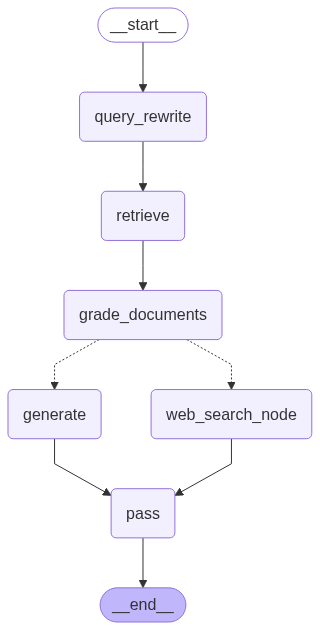

In [17]:
crag.app

In [13]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(crag.app)

AttributeError: 'CRAG' object has no attribute 'app'

In [ ]:
answer, answer_state = crag.invoke(question=question)
answer, answer_state


==== [REWRITE QUERY] ====


==== RETRIEVE ====


==== [CHECK DOCUMENT RELEVANCE TO QUESTION] ====

==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [GRADE: DOCUMENT NOT RELEVANT] ====

==== [WEB SEARCH] ====

==== [PASS THROUGH] ====
Final Answer: 삼성전자가 개발한 생성형 인공지능(AI) 모델의 이름은 '삼성 가우스(Samsung Gauss)'입니다. 이 AI 모델은 머신 러닝 기술을 기반으로 언어 모델, 코드 모델, 이미지 모델 등 3가지 모델로 구성되어 있습니다. 언어 모델은 클라우드와 온디바이스를 위한 다양한 모델로 이루어져 있으며, 메일 작성과 문서 요약, 번역 등의 업무를 더 쉽고 빠르게 처리할 수 있게 도와줍니다. 코드 모델을 기반으로 한 AI 코딩 어시스턴트 '코드아이'는 소프트웨어 개발에서 개발자들이 코딩을 더 쉽고 빠르게 할 수 있도록 지원하며, 이미지 모델은 창의적인 이미지를 만들고 기존 이미지를 원하는 대로 수정할 수 있게 도와줍니다.
삼성전자가 개발한 생성형 AI의 이름은 무엇인가요?
삼성전자가 개발한 생성형 인공지능(AI) 모델의 이름은 '삼성 가우스(Samsung Gauss)'입니다. 이 AI 모델은 머신 러닝 기술을 기반으로 언어 모델, 코드 모델, 이미지 모델 등 3가지 모델로 구성되어 있습니다. 언어 모델은 클라우드와 온디바이스를 위한 다양한 모델로 이루어져 있으며, 메일 작성과 문서 요약, 번역 등의 업무를 더 쉽고 빠르게 처리할 수 있게 도와줍니다. 코드 모델을 기반으로 한 AI 코딩 어시스턴트 '코드아이'는 소프트웨어 개발에서 개발자들이 코딩을 더 쉽고 빠르게 할 수 있도록 지원하며, 이미지 

("삼성전자가 개발한 생성형 AI의 이름은 무엇인가요?\n삼성전자가 개발한 생성형 인공지능(AI) 모델의 이름은 '삼성 가우스(Samsung Gauss)'입니다. 이 AI 모델은 머신 러닝 기술을 기반으로 언어 모델, 코드 모델, 이미지 모델 등 3가지 모델로 구성되어 있습니다. 언어 모델은 클라우드와 온디바이스를 위한 다양한 모델로 이루어져 있으며, 메일 작성과 문서 요약, 번역 등의 업무를 더 쉽고 빠르게 처리할 수 있게 도와줍니다. 코드 모델을 기반으로 한 AI 코딩 어시스턴트 '코드아이'는 소프트웨어 개발에서 개발자들이 코딩을 더 쉽고 빠르게 할 수 있도록 지원하며, 이미지 모델은 창의적인 이미지를 만들고 기존 이미지를 원하는 대로 수정할 수 있게 도와줍니다.",
 1)